# Frequency Distribution

## Imports

In [1]:
from helper import *
from caen_digitizer import *

# data
import uproot
import numpy as np
import awkward as ak
import polars as pl
from tqdm import tqdm

# plotting
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from collections import Counter

In [2]:
plt.rcParams.update({
    "figure.figsize": (6,4),
    "font.size": 10, 
    "legend.fontsize": 13, 
    "legend.labelspacing": 0.2, 
    "figure.dpi": 100, 
    "text.usetex": False,
    "text.latex.preamble": r"\usepackage{sfmath}",
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
})

## Retrieve data

In [3]:
#Set file directory
# fileDir = "/Users/andyyu/Documents/Python/HEP/dawson_hep/scintillating_chamber/data_analysis/data"
fileDir = "H:/bl4s/DATA/dawsons/"

# list of run numbers to load
run_indices = np.concatenate([np.arange(1, 17 + 1), np.arange(19, 35 + 1)])
print(run_indices)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35]


In [79]:
#Read every data and put it into a list
dfs = []
for i in tqdm(run_indices):
    data = digitizer(f'{fileDir}/run{i:06}.root', events=None, channels=[i for i in range(17, 27) ], signal_filter='converted')
    dfs.append(data)

100%|██████████| 34/34 [02:18<00:00,  4.08s/it]


In [5]:
# Interleaving
dfs_interleaved = []
set_a, set_b = dfs[:17], dfs[17:]
print(f"{len(dfs)} {len(set_a)} {len(set_b)}")

for (a, b) in zip(set_a, set_b):
    dfs_interleaved.append(a)
    dfs_interleaved.append(b)

dfs_interleaved

34 17 17


## Masking Function

In [6]:
def getMaxMask(data, getMask, n):
    #Create a mask
    ch_event = getMask(0, data, n)

    #Loop through all the channels and see which has the most hits after masking
    for _channel_trigger in range(1,10):

        masked = getMask(_channel_trigger, data, n)


        if masked[0].shape[0] > ch_event[0].shape[0]:
            ch_event = masked
    

    return ch_event[0]


def getThresholdMask(_channel_trigger, data, threshold):

    #Create the threshold mask
    signal_max = data.waveforms['amplitude'][:, _channel_trigger]
    signal_min = data.waveforms['wave'][:, _channel_trigger].min(axis=1)
    mask_event = (signal_min > -15) & (signal_max > threshold)

    return np.where(mask_event)

def getSNRMask(_channel_trigger, data, SNR_factor):

    #Set the number of samples we want to take to get the mean of the noise
    samples = 50
    sample_head = data.waveforms["wave"][2][_channel_trigger][:samples]

    mean = np.mean(np.abs(sample_head))

    #Calculate signal to noise ratio
    SNR = sample_head.max() / mean

    
    #Generate the mask with SNR * SNR_factor as the threshold
    signal_max = data.waveforms['amplitude'][:, _channel_trigger]
    signal_min = data.waveforms['wave'][:, _channel_trigger].min(axis=1)
    # mask_event = (signal_min > -15) & (signal_max > SNR * SNR_factor)
    mask_event = (signal_min > -15) & (SNR > SNR_factor)

    return np.where(mask_event)

getSNRMask(2, dfs[0], 2)


(array([   0,    1,    2, ..., 9997, 9998, 9999], shape=(9998,)),)

In [7]:
## Per-channel triggering & counting

def getChannelMask(data, getMask, n, channel):
    #Create a mask
    return getMask(channel, data, n)[0]

n = 10

channel_rates_interleaved = np.empty((10, 34), dtype=np.float32)
for ch in range(0, 10):
    rates = channel_rates_interleaved[ch]

    for i, file in enumerate(dfs_interleaved):
        selected_events = len(getChannelMask(file, getThresholdMask, n, ch))
        rates[i] = selected_events / len(file.waveforms['wave'])

## Get Rates

In [8]:

def getRates(dfs, n, mask_f = getThresholdMask):
    rates = []

    #Loop through every file and find the maximum rate of each
    for file in dfs:
        #find number of events triggered
        selected_events = len(getMaxMask(file, mask_f, n))
        #divide by total events
        r = selected_events / len(file.waveforms['wave'])

        rates.append(r)
    return rates

threshold_rates = getRates(dfs, 10)
print(threshold_rates)
print(len(threshold_rates))

threshold_rates_interleaved = getRates(dfs_interleaved, 10)
print(threshold_rates_interleaved)
print(len(threshold_rates_interleaved))

# #Loop through every factor to determine which gives the best result
# all_SNR_rates = []
# for factor in range(2,7):
#     SNR_rates = getRates(dfs, factor ,mask_f = getSNRMask)   
#     all_SNR_rates.append(SNR_rates)

[0.1557, 0.5585, 0.8152, 0.8485, 0.8443, 0.8501, 0.8039, 0.5719, 0.7622, 0.847, 0.8567, 0.847, 0.8231, 0.7613, 0.4064, 0.0832, 0.0244, 0.3499, 0.7738, 0.8469, 0.8525, 0.8515, 0.845, 0.7432, 0.603, 0.8371, 0.8531, 0.8578, 0.8534, 0.8396, 0.6177, 0.1603, 0.0229, 0.0215]
34
[0.1557, 0.3499, 0.5585, 0.7738, 0.8152, 0.8469, 0.8485, 0.8525, 0.8443, 0.8515, 0.8501, 0.845, 0.8039, 0.7432, 0.5719, 0.603, 0.7622, 0.8371, 0.847, 0.8531, 0.8567, 0.8578, 0.847, 0.8534, 0.8231, 0.8396, 0.7613, 0.6177, 0.4064, 0.1603, 0.0832, 0.0229, 0.0244, 0.0215]
34


In [9]:
k1 = 34
#Threshold: reorder all the data for position
set1 = threshold_rates[:17]
set2 = threshold_rates[17:]
total_threshold_rates = []
for i in range(k1//2):
    total_threshold_rates.append(set1[i])
    total_threshold_rates.append(set2[i])


# #SNR: reorder all the data for position
# total_SNR_rates = []
# for SNR_rates in all_SNR_rates:
#     set1 = SNR_rates[:17 - ROYAL_FUCK_UP_FIX]
#     set2 = SNR_rates[17 + ROYAL_FUCK_UP_FIX:34]
    
#     l = []
#     for i in range(k1//2 - ROYAL_FUCK_UP_FIX):
#         l.append(set1[i])
#         l.append(set2[i])
    
#     total_SNR_rates.append(l)


# total
print(total_threshold_rates)
print(len(total_threshold_rates))
# print(total_SNR_rates)

[0.1557, 0.3499, 0.5585, 0.7738, 0.8152, 0.8469, 0.8485, 0.8525, 0.8443, 0.8515, 0.8501, 0.845, 0.8039, 0.7432, 0.5719, 0.603, 0.7622, 0.8371, 0.847, 0.8531, 0.8567, 0.8578, 0.847, 0.8534, 0.8231, 0.8396, 0.7613, 0.6177, 0.4064, 0.1603, 0.0832, 0.0229, 0.0244, 0.0215]
34


In [39]:
# total
# print(total_threshold_rates)
# print(total_SNR_rates)

# total_threshold_rates = [0.1557, 0.1526, 0.5585, 0.3499, 0.8152, 0.7738, 0.8485, 0.8469, 0.8443, 0.8525, 0.8501, 0.8515, 0.8039, 0.845, 0.5719, 0.7432, 0.7622, 0.603, 0.847, 0.8371, 0.8567, 0.8531, 0.847, 0.8578, 0.8231, 0.8534, 0.7613, 0.8396, 0.4064, 0.6177, 0.0832, 0.1603, 0.0244, 0.0229]
# total_SNR_rates = [[0.1591, 0.7859, 0.8211, 0.3826, 0.8157, 0.7749, 0.8489, 0.8472, 0.8444, 0.8527, 0.8502, 0.8517, 0.805, 0.8454, 0.7311, 0.757, 0.7654, 0.606, 0.8474, 0.8381, 0.8568, 0.8534, 0.8473, 0.8581, 0.8251, 0.8536, 0.7721, 0.84, 0.4564, 0.6191, 0.3683, 0.5859, 0.5828, 0.5838], [0.1559, 0.1533, 0.5571, 0.3544, 0.8152, 0.773, 0.8488, 0.8469, 0.8444, 0.8525, 0.8501, 0.8515, 0.8043, 0.8453, 0.5713, 0.7434, 0.7638, 0.6013, 0.8471, 0.8374, 0.8568, 0.853, 0.847, 0.8579, 0.8242, 0.8534, 0.7628, 0.8397, 0.4069, 0.6177, 0.0832, 0.16, 0.0265, 0.0576], [0.153, 0.1513, 0.5545, 0.3513, 0.8147, 0.7719, 0.8484, 0.8466, 0.8443, 0.8524, 0.85, 0.8515, 0.8032, 0.845, 0.5673, 0.7418, 0.7627, 0.5957, 0.8464, 0.8371, 0.8567, 0.853, 0.8469, 0.8578, 0.8237, 0.8534, 0.7621, 0.8393, 0.404, 0.6159, 0.0819, 0.1588, 0.0249, 0.0194], [0.1508, 0.1491, 0.5506, 0.3483, 0.8143, 0.7701, 0.8482, 0.8464, 0.8443, 0.8521, 0.8499, 0.8514, 0.8027, 0.8448, 0.5637, 0.7404, 0.7617, 0.5911, 0.8463, 0.8365, 0.8566, 0.853, 0.8466, 0.8577, 0.8229, 0.8533, 0.7611, 0.8392, 0.4019, 0.6145, 0.0811, 0.1572, 0.024, 0.0187], [0.1485, 0.1467, 0.5472, 0.3457, 0.8137, 0.7686, 0.8481, 0.8462, 0.8443, 0.8519, 0.8498, 0.8514, 0.8022, 0.8444, 0.5602, 0.7392, 0.7604, 0.5875, 0.8462, 0.8362, 0.8564, 0.8529, 0.8465, 0.8577, 0.8227, 0.8531, 0.7601, 0.8388, 0.4, 0.6131, 0.0797, 0.1552, 0.0235, 0.0181]]

In [10]:
#Calculate in which position the graph dips
dip = []
for i in range(len(total_threshold_rates) - 1):
    if total_threshold_rates[i] < total_threshold_rates[i+1]:
        dip.append(i)
dip

[0, 1, 2, 3, 4, 5, 6, 8, 14, 15, 16, 17, 18, 19, 20, 22, 24, 31]

In [11]:
#Generate x and y vertices for the data
# x = np.linspace(0,80,34 - ROYAL_FUCK_UP_FIX * 2)
x = np.linspace(0,80,k1)
plt.figure(figsize=(10, 10))

# #Smoothing the line
# # moving average
# window = 5  # number of points to average
# #Basically, this line creates a matrix of length window, and divides it(meaning it is taking the mean), 
# y_s = np.convolve(y, np.ones(window)/window, mode='same')


#Plot threshold data
y_t = np.array(fig_data_reference)
plt.plot(x,np.array(total_threshold_rates), color = "blue", label = f"total_threshold_rates")
plt.plot(x,np.array(threshold_rates_interleaved), color = "red", label = f"threshold_rates_interleaved")
# plt.fill_between(x,y_t, color= "skyblue", alpha = 0.2)

for i, ch in enumerate(channel_rates_interleaved[0:6]):
    plt.plot(x, ch, label=f"Channel {i}")

# colour = [("forestgreen", "palegreen"), ("gold", "lemonChiffon"), ("firebrick", "lightcoral"), ("chocolate","sandybrown"), ("darkturquoise", "paleturquoise") ]
# # #Loop through all the SNR rates and plot them
# tSNR_rates = total_SNR_rates[:5]
# for k ,r in enumerate(tSNR_rates):
#     y_s = np.array(r)
#     plt.plot(x,y_s, color = colour[k][0], label = f"SNR * {k + 2}")
#     # plt.fill_between(x, y_s, color= colour[k][1], alpha = 0.2)


plt.xticks(np.arange(0,80,4))
plt.yticks(np.arange(0,1,0.1))

plt.xlabel("Position(mm)")
plt.ylabel("Detection efficiency")
plt.title("Detection efficiency at different positions")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()


NameError: name 'fig_data_reference' is not defined

<Figure size 1000x1000 with 0 Axes>

## Binary Events Activation

In [103]:
all_waveforms = np.empty((34, 10000, 10, 924), dtype=np.float32)
all_integrals = np.empty((34, 10000, 10), dtype=np.float32)
all_tot = np.empty((34, 10000, 10), dtype=np.float32)

for i, file in enumerate(dfs_interleaved):
    all_waveforms[i] = file.waveforms['wave']
    all_integrals[i] = file.waveforms['integral']
    all_tot[i] = file.waveforms['tot']

print(all_waveforms.shape)

(34, 10000, 10, 924)


In [13]:
signal_max, signal_min = all_waveforms.max(axis=-1), all_waveforms.min(axis=-1)
print(signal_max.shape, signal_min.shape)

(34, 10000, 10) (34, 10000, 10)


In [14]:
trigger = (signal_min > -15) & (signal_max > 10)
trigger = trigger[:, :, :6]
print(trigger.shape)

(34, 10000, 6)


In [15]:
trigger_no = (trigger * 2**np.arange(0, 6)).sum(axis=-1)
print(trigger_no.shape)

(34, 10000)


In [16]:
item_counts = np.zeros((34, 64), dtype=int)

for i, pos_trigger in enumerate(trigger_no):
    idx, counts = np.unique(pos_trigger, return_counts=True)
    item_counts[i, idx] = counts

trigger_per_bin_type = np.transpose(item_counts / 10000)
trigger_per_bin_type

array([[8.206e-01, 6.333e-01, 4.213e-01, ..., 9.628e-01, 9.586e-01,
        9.769e-01],
       [9.000e-04, 5.000e-04, 6.000e-04, ..., 1.120e-02, 1.040e-02,
        5.400e-03],
       [6.000e-04, 3.000e-04, 0.000e+00, ..., 7.000e-04, 7.000e-04,
        4.000e-04],
       ...,
       [0.000e+00, 3.000e-04, 1.000e-04, ..., 0.000e+00, 1.000e-04,
        0.000e+00],
       [0.000e+00, 0.000e+00, 5.000e-04, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [1.000e-04, 1.000e-04, 0.000e+00, ..., 0.000e+00, 1.000e-04,
        0.000e+00]], shape=(64, 34))

In [17]:
top_bin_types = np.argsort(trigger_per_bin_type.mean(axis=-1))[::-1]
kept_top_bin_types = top_bin_types[:10]

In [18]:
cumulative_trigger_efficiency = trigger_per_bin_type[1:].sum(axis=0)   # ignore state 000000 (no sensor fired), include single sensor fires.
cumulative_trigger_efficiency

valid_indices = [
    0b01_0001,
    0b01_0010,
    0b10_0100,
    0b10_1000,
] # valid reconstruction sensor states

valid_binary_reconstruction_efficiency = trigger_per_bin_type[valid_indices].sum(axis=0)
valid_binary_reconstruction_efficiency

array([0.1091, 0.2394, 0.4741, 0.6998, 0.7857, 0.8193, 0.7805, 0.7409,
       0.7009, 0.7401, 0.7541, 0.7959, 0.7289, 0.6689, 0.5538, 0.5861,
       0.6475, 0.7731, 0.7851, 0.7945, 0.7365, 0.6968, 0.6869, 0.773 ,
       0.7618, 0.7518, 0.5367, 0.3457, 0.1534, 0.0433, 0.0295, 0.0119,
       0.0162, 0.0082])

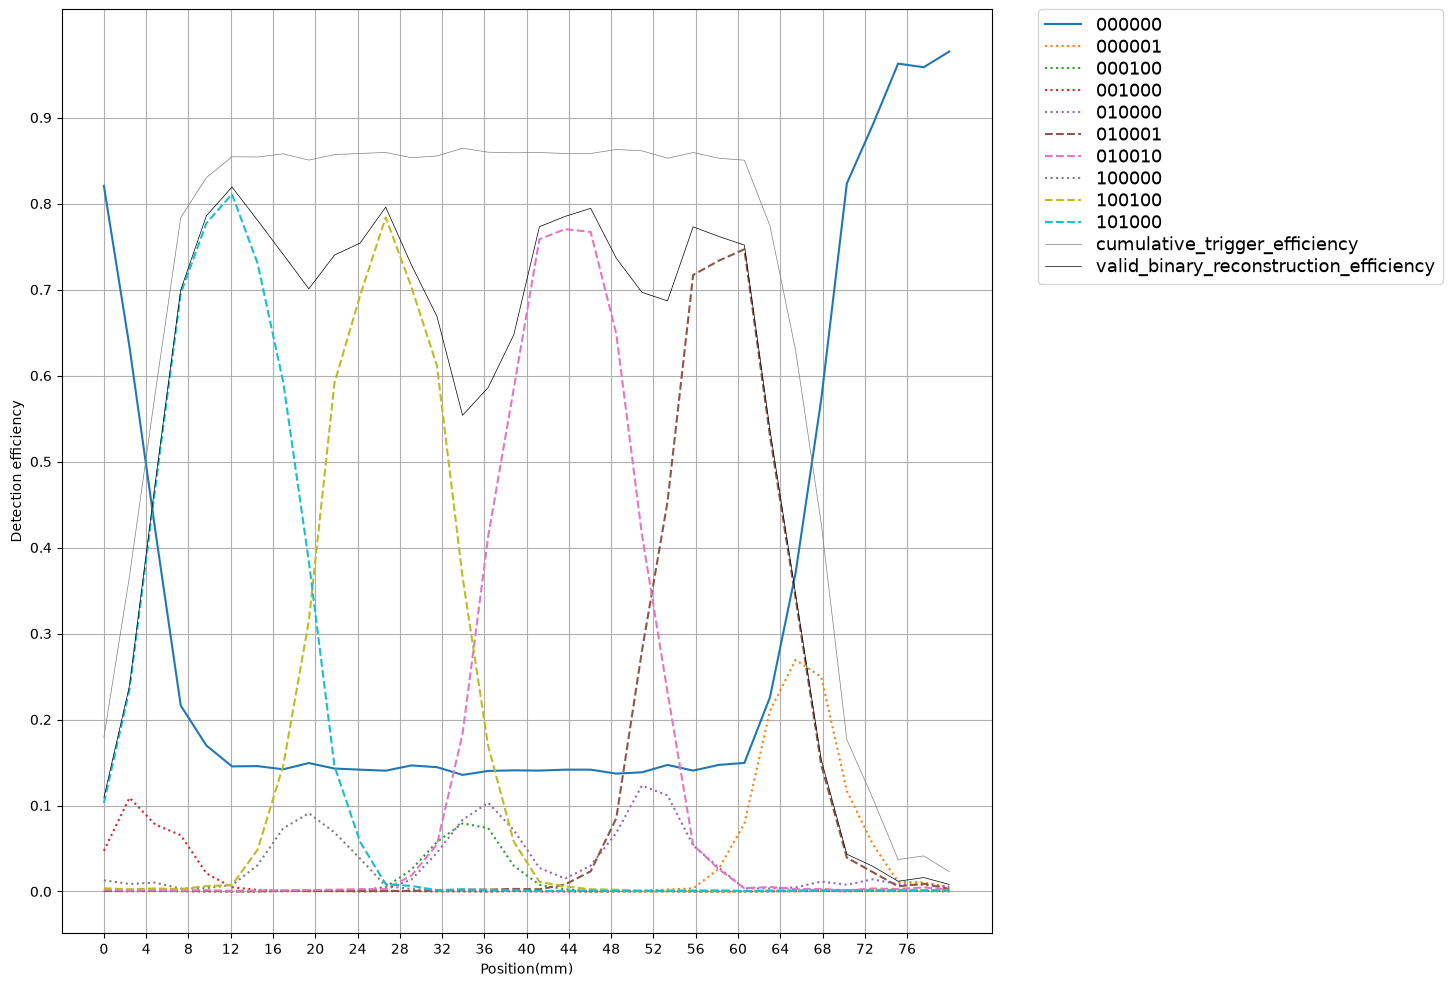

In [19]:
#Generate x and y vertices for the data
# x = np.linspace(0,80,34 - ROYAL_FUCK_UP_FIX * 2)
x = np.linspace(0,80,k1)
plt.figure(figsize=(12, 12))


## plot top binary sensor-state trigger types
for bin_type, rate in enumerate(trigger_per_bin_type):
    if bin_type not in kept_top_bin_types:
        continue
    match bin_type.bit_count():
        case 0:
            style="solid"
        case 1:
            style="dotted"
        case 2:
            style="dashed"
        case 3:
            style="dashdot"
        case _:
            style="solid"
            
    plt.plot(x, rate, label=f"{f"{bin_type:06b}"}", linestyle=style)

# plot non-zero trigger state ratio
plt.plot(x, cumulative_trigger_efficiency, label="cumulative_trigger_efficiency", linestyle="solid", linewidth=0.5, color="grey")
# plot recontruction state ratio
plt.plot(x, valid_binary_reconstruction_efficiency, label="valid_binary_reconstruction_efficiency", linestyle="solid", linewidth=0.5, color="black")

plt.xticks(np.arange(0,80,4))
plt.yticks(np.arange(0,1,0.1))

plt.xlabel("Position(mm)")
plt.ylabel("Detection efficiency")
# plt.title("Detection efficiency at different positions")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

In [212]:
sum_at_loc = trigger_per_bin_type.T[:, 1:].sum(axis=-1)

norm_trigger_per_bin_type = np.transpose(trigger_per_bin_type.T[:, 1:] / sum_at_loc.reshape((-1, 1)))
norm_valid_binary_reconstruction_efficiency = norm_trigger_per_bin_type[np.array(valid_indices) -1].sum(axis=0)

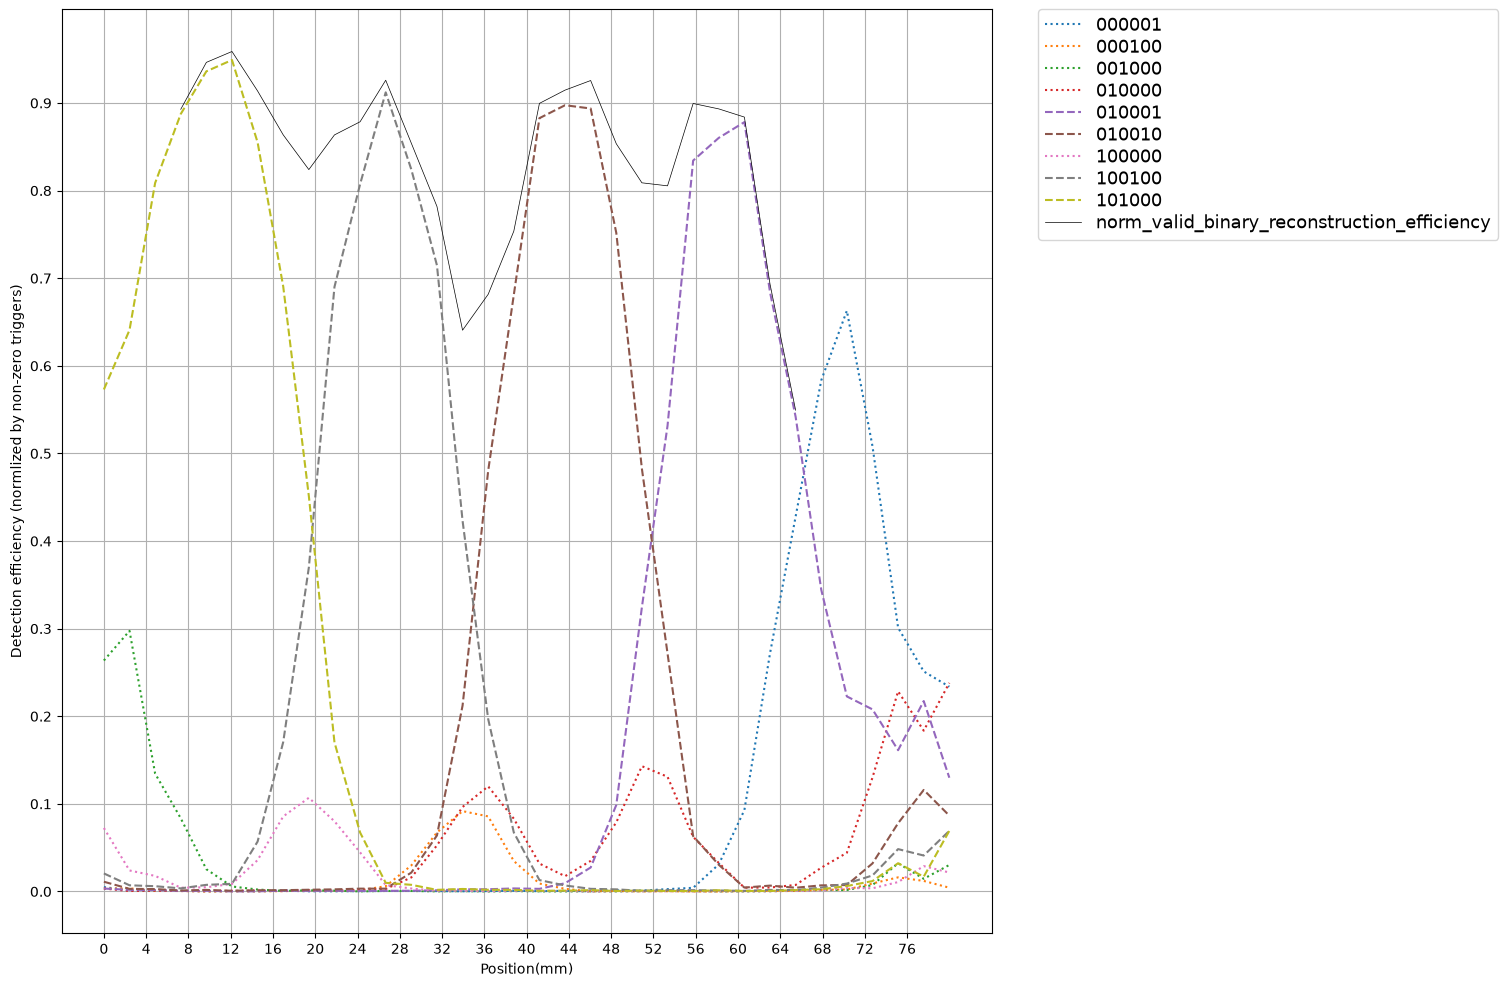

In [213]:
#Generate x and y vertices for the data
# x = np.linspace(0,80,34 - ROYAL_FUCK_UP_FIX * 2)
x = np.linspace(0,80,k1)
plt.figure(figsize=(12, 12))


## plot top binary sensor-state trigger types
for i, rate in enumerate(norm_trigger_per_bin_type):
    bin_type = i + 1
    if bin_type not in kept_top_bin_types:
        continue
    match bin_type.bit_count():
        case 0:
            style="solid"
        case 1:
            style="dotted"
        case 2:
            style="dashed"
        case 3:
            style="dashdot"
        case _:
            style="solid"
            
    plt.plot(x, rate, label=f"{f"{bin_type:06b}"}", linestyle=style)

# plot recontruction state ratio
plt.plot(x[3:-6], norm_valid_binary_reconstruction_efficiency[3:-6], label="norm_valid_binary_reconstruction_efficiency", linestyle="solid", linewidth=0.5, color="black")

# plt.axhline(y=1)

plt.xticks(np.arange(0,80,4))
plt.yticks(np.arange(0,1,0.1))

plt.xlabel("Position(mm)")
plt.ylabel("Detection efficiency (normlized by non-zero triggers)")
# plt.title("Detection efficiency at different positions")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

## Formatted LateX Graph

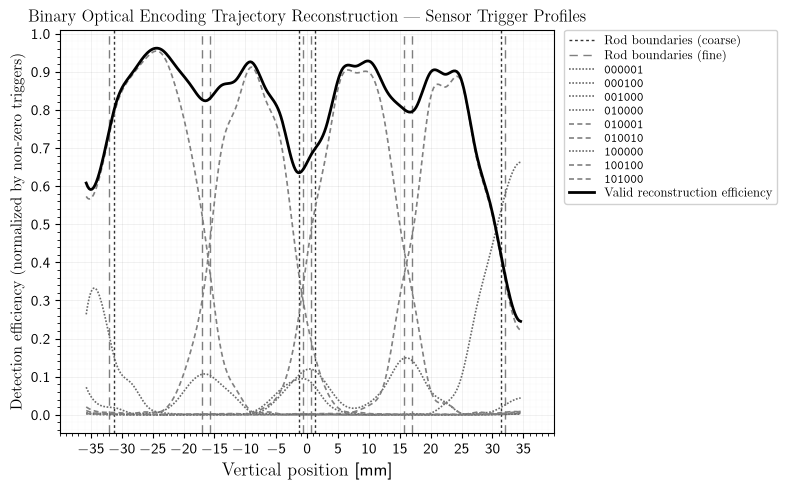

In [238]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc
from scipy.interpolate import make_interp_spline

# LaTeX and serif font setup
rc('text', usetex=True)
rc('font', family='serif')

# Define x domain and centering offset (-37.5 mm)
x = np.linspace(0, 80, k1)
x_centered = x - 35.75

# Mask boundaries to avoid edge artifacts
mask = np.abs(x_centered) < 36
x_centered_masked = x_centered[mask]
x_smooth = np.linspace(x_centered_masked.min(), x_centered_masked.max(), 300)

fig, ax = plt.subplots(figsize=(8, 5))

# Plot coarse rod boundaries (densely dotted)
coarse_lines = [-31.33, -1.33, 1.33, 31.33]
coarse_drawn = False
for xv in coarse_lines:
    label = r'Rod boundaries (coarse)' if not coarse_drawn else None
    ax.axvline(
        xv, color='black', linewidth=1.0, linestyle=(0, (2, 2)), alpha=0.8, label=label
    )
    coarse_drawn = True

# Plot fine rod boundaries (loosely dashed)
fine_lines = [
    -32.00,
    -17.00,
    -15.667,
    -0.667,
    0.667,
    15.667,
    17.00,
    32.00,
]
fine_drawn = False
for xv in fine_lines:
    label = r'Rod boundaries (fine)' if not fine_drawn else None
    ax.axvline(
        xv, color='black', linewidth=1.0, linestyle=(0, (6, 4)), alpha=0.5, label=label
    )
    fine_drawn = True

# Black & White / Grayscale linestyles and gray shades mapped by bit count
style_map = {
    0: {'ls': '-', 'color': 'black', 'lw': 1.2},
    1: {'ls': (0, (1, 1)), 'color': 'dimgray', 'lw': 1.2},
    2: {'ls': (0, (3, 2)), 'color': 'gray', 'lw': 1.2},
    3: {'ls': (0, (5, 2, 1, 2)), 'color': 'darkgray', 'lw': 1.2},
}

# Plot binary sensor-state trigger types
for i, rate in enumerate(norm_trigger_per_bin_type):
    bin_type = i + 1
    if bin_type not in kept_top_bin_types:
        continue

    rate_masked = np.array(rate)[mask]

    # Smooth curve fitting
    spline = make_interp_spline(x_centered_masked, rate_masked, k=3)
    y_smooth = spline(x_smooth)

    bit_cnt = bin_type.bit_count()
    cfg = style_map.get(bit_cnt, {'ls': '-', 'color': 'black', 'lw': 1.0})

    bit_str = f'{bin_type:06b}'
    ax.plot(
        x_smooth,
        y_smooth,
        label=rf'$\mathtt{{{bit_str}}}$',
        linestyle=cfg['ls'],
        color=cfg['color'],
        linewidth=cfg['lw'],
    )

# Plot valid binary reconstruction efficiency (prominent solid black curve)
y_rec_masked = np.array(norm_valid_binary_reconstruction_efficiency)[mask]
spline_rec = make_interp_spline(x_centered_masked, y_rec_masked, k=3)
y_rec_smooth = spline_rec(x_smooth)

ax.plot(
    x_smooth,
    y_rec_smooth,
    label=r'Valid reconstruction efficiency',
    color='black',
    linestyle='-',
    linewidth=2.0,
)

# Axis limits, ticks, and labels
ax.set_xlim(-40, 40)
ax.set_xticks(np.arange(-35, 40, 5))
ax.set_yticks(np.arange(0, 1.1, 0.1))

ax.set_xlabel(r'Vertical position $[\mathrm{mm}]$', fontsize=13)
ax.set_ylabel(
    r'Detection efficiency (normalized by non-zero triggers)', fontsize=11
)
ax.set_title(
    r'Binary Optical Encoding Trajectory Reconstruction — Sensor Trigger Profiles',
    fontsize=12,
)

# Grid and tick parameters
ax.tick_params(labelsize=11)
ax.grid(which='major', lw=0.4, ls='-', color='gray', alpha=0.2)
ax.grid(which='minor', lw=0.3, ls=':', color='gray', alpha=0.15)
ax.minorticks_on()

# Legend positioning outside or tightly integrated
ax.legend(
    fontsize=9,
    framealpha=0.9,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
)

fig.tight_layout()
fig.savefig('binary_reconstruction_efficiency.pdf', dpi=300, bbox_inches='tight')
fig.savefig('binary_reconstruction_efficiency.png', dpi=300, bbox_inches='tight')
plt.show()

## ADC Event Example per type.

In [110]:
valid_data = []

class ValidData:
    def __init__(self, wave, integral, tot):
        self.waveform = wave
        self.integral = integral
        self.tot = tot

for valid_i in valid_indices:
    loc = np.argwhere(trigger_no == valid_i)

    x, y = loc.T
    loc_waveforms = all_waveforms[x, y]
    loc_integrals = all_integrals[x, y]
    loc_tot = all_tot[x, y]

    print(loc_waveforms.shape)
    print(loc_integrals.shape)
    print(loc_tot.shape)

    valid_data.append(ValidData(loc_waveforms, loc_integrals, loc_tot))


(41642, 10, 924)
(41642, 10)
(41642, 10)
(49758, 10, 924)
(49758, 10)
(49758, 10)
(45517, 10, 924)
(45517, 10)
(45517, 10)
(50377, 10, 924)
(50377, 10)
(50377, 10)


<>:77: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:77: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:78: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:78: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:132: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:77: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:77: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences wi

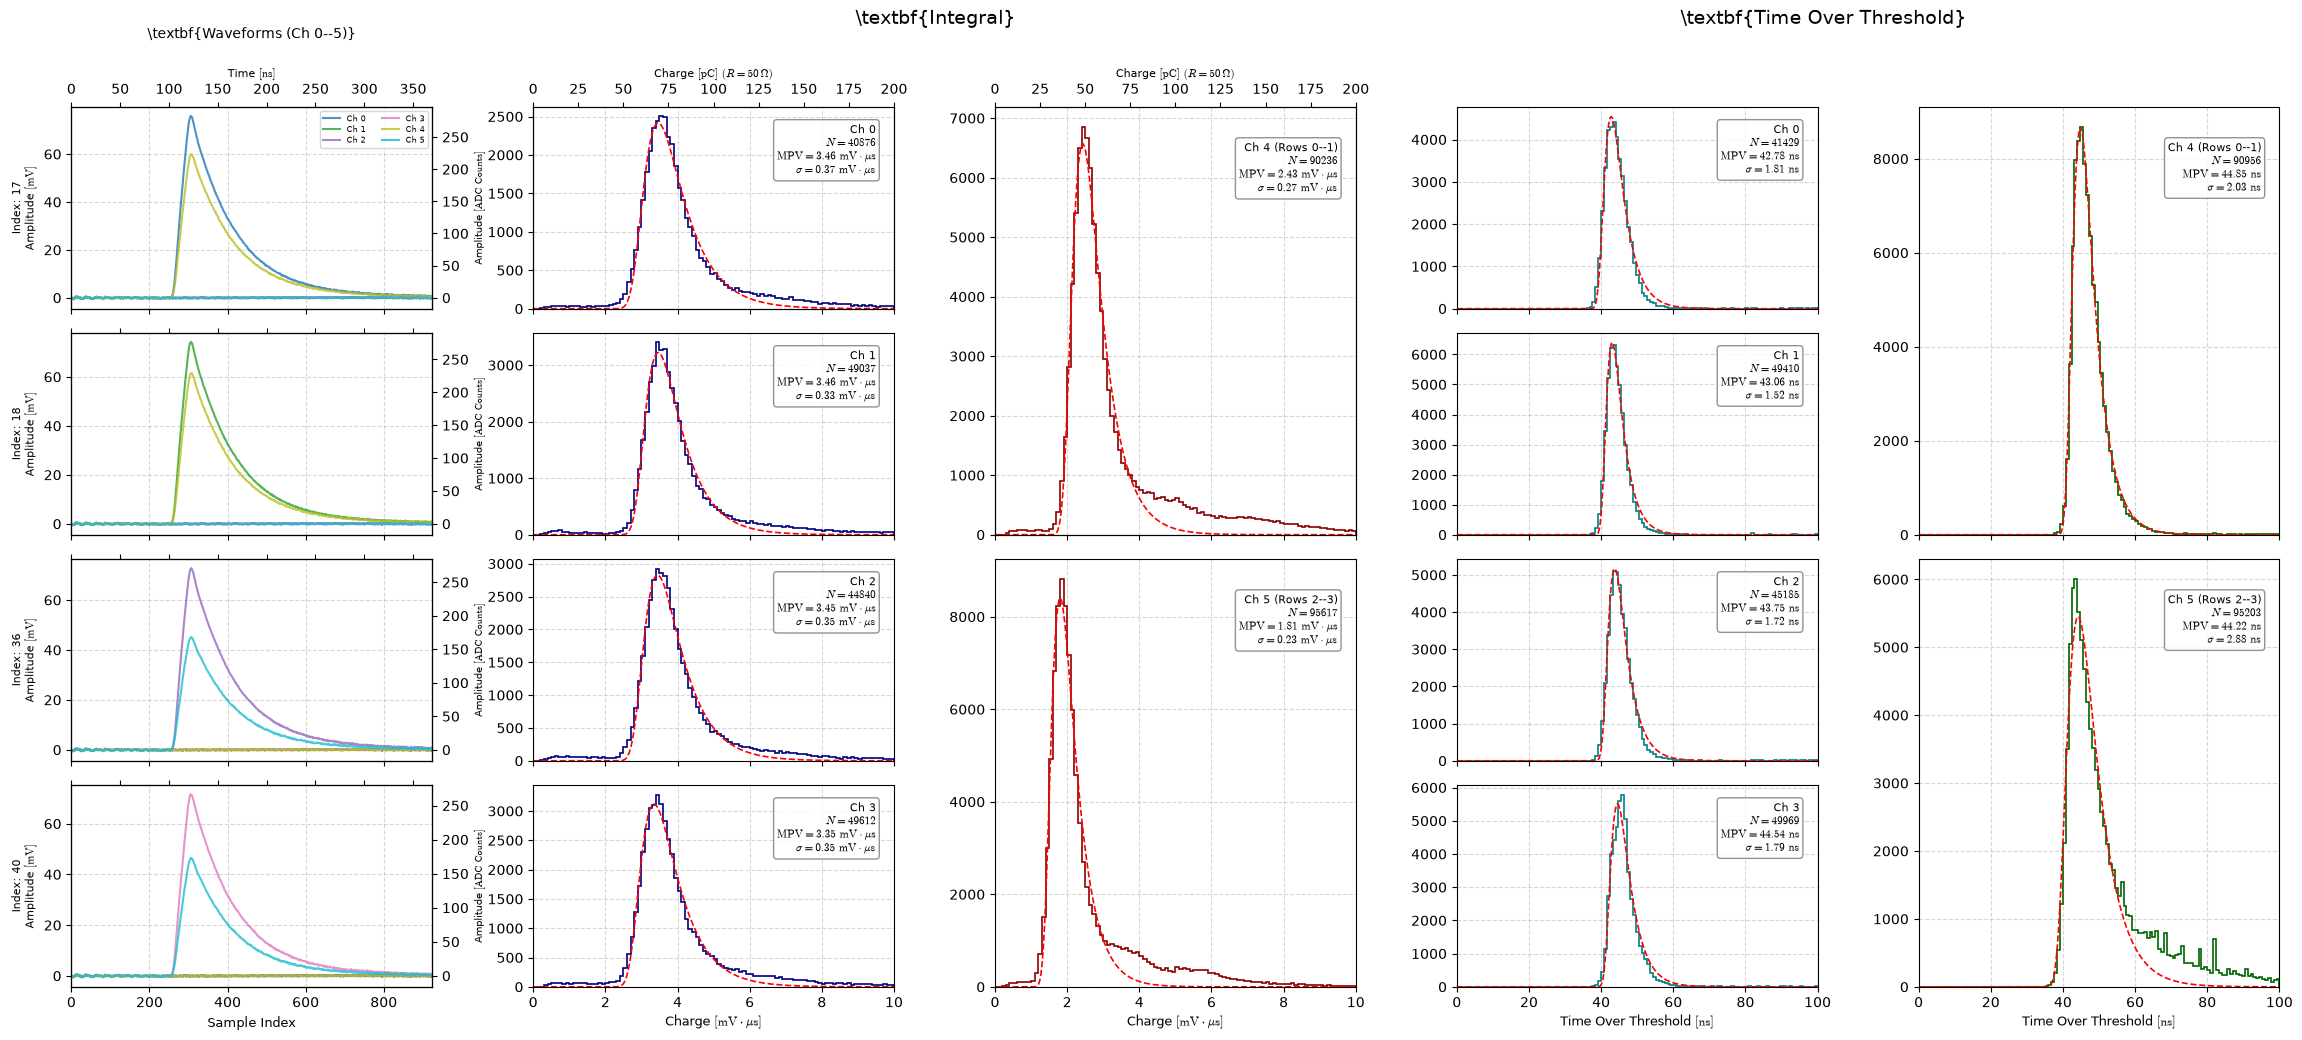

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import moyal
from scipy.optimize import curve_fit

# TeX styling in Matplotlib
plt.rcParams['text.usetex'] = False  # Set to True if local LaTeX distribution is installed
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['mathtext.fontset'] = 'cm'  # Computer Modern TeX style math font

# ===== 1. CONVERSION CONSTANTS & CONFIGURATION =====
ADC_CONVERSION = 1.1 * 1000 / (2**12)  # mV per ADC count (0.26855 mV/ADC)
TIME_PER_SAMPLE = 0.4                  # ns per sample (2.5 GS/s)
IMPEDANCE = 50.0                       # Ohms (standard signal termination)

# Adjustable x-axis bounds
X_BOUNDS_WAVE_SAMPLES = (0, 924)       # Sample Index range
X_BOUNDS_INT_CHARGE_MV_US = (0, 10)    # Integral bounds in [mV * us]
X_BOUNDS_TOT_SAMPLES = (0, 250)        # Raw ToT bounds in samples

# Converted bounds for waveforms and ToT
X_BOUNDS_WAVE_NS = (X_BOUNDS_WAVE_SAMPLES[0] * TIME_PER_SAMPLE, X_BOUNDS_WAVE_SAMPLES[1] * TIME_PER_SAMPLE)
X_BOUNDS_TOT_NS  = (X_BOUNDS_TOT_SAMPLES[0] * TIME_PER_SAMPLE, X_BOUNDS_TOT_SAMPLES[1] * TIME_PER_SAMPLE)

# Bin counts
NUM_BINS_INT = 100
NUM_BINS_TOT = 125

# Layout Spacing
ROW_HSPACE = 0.12
COL_WSPACE = 0.28


# ===== 2. FIT FUNCTION & PLOTTING HELPER =====
def landau_func(x, amplitude, mpv, sigma):
    return amplitude * moyal.pdf(x, loc=mpv, scale=sigma)

def plot_hist_with_landau_fit(ax, data, x_range, num_bins, color, title=None, 
                              ch_label="", show_xlabel=False, xlabel="", unit_str=""):
    data_clean = data[~np.isnan(data)]
    data_filtered = data_clean[(data_clean >= x_range[0]) & (data_clean <= x_range[1])]
    
    counts, bin_edges = np.histogram(data_filtered, bins=num_bins, range=x_range)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Histogram outline
    ax.hist(data_filtered, bins=num_bins, range=x_range, histtype='step', 
            linewidth=1.2, color=color, label='Data')
    
    n_count = len(data_filtered)
    sample_mpv = bin_centers[np.argmax(counts)] if n_count > 0 else (x_range[0] + x_range[1]) / 2
    sample_sigma = np.std(data_filtered) / 2.0 if n_count > 0 else 1.0
    
    mpv_val, sigma_val = sample_mpv, sample_sigma
    
    # Landau Fit
    if n_count > 5 and sample_sigma > 0:
        bin_width = bin_edges[1] - bin_edges[0]
        p0 = [np.max(counts) * bin_width * 2, sample_mpv, sample_sigma]
        try:
            popt, _ = curve_fit(
                landau_func, bin_centers, counts, p0=p0, 
                bounds=(0, [np.inf, x_range[1], (x_range[1] - x_range[0]) / 2]), 
                maxfev=2000
            )
            amp_val, mpv_val, sigma_val = popt
            
            x_fit = np.linspace(x_range[0], x_range[1], 300)
            y_fit = landau_func(x_fit, amp_val, mpv_val, sigma_val)
            ax.plot(x_fit, y_fit, 'r--', linewidth=1.2, label='Landau Fit')
        except Exception:
            pass
            
    stats_text = (
        f"Ch {ch_label}\n"
        f"$N = {n_count}$\n"
        f"$\mathrm{{MPV}} = {mpv_val:.2f}\ \mathrm{{{unit_str}}}$\n"
        f"$\sigma = {sigma_val:.2f}\ \mathrm{{{unit_str}}}$"
    )
    ax.text(0.95, 0.92, stats_text, transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='gray'))
    
    ax.set_xlim(x_range)
    if title:
        ax.set_title(title, fontsize=10, pad=6)
        
    if not show_xlabel:
        ax.tick_params(labelbottom=False)
    else:
        ax.set_xlabel(xlabel, fontsize=9)


# ===== 3. BUILD GRID & AXES =====
fig = plt.figure(figsize=(24, 11))
gs = fig.add_gridspec(nrows=4, ncols=5, hspace=ROW_HSPACE, wspace=COL_WSPACE)

channel_colors = plt.cm.tab10(np.linspace(0, 1, 6))
left_channels = [0, 1, 2, 3]

# Create axes for Left Columns
ax_wave = [fig.add_subplot(gs[r, 0]) for r in range(4)]

ax_int_left = []
for r in range(4):
    ax = fig.add_subplot(gs[r, 1], sharex=ax_int_left[0] if r > 0 else None)
    ax_int_left.append(ax)

ax_tot_left = []
for r in range(4):
    ax = fig.add_subplot(gs[r, 3], sharex=ax_tot_left[0] if r > 0 else None)
    ax_tot_left.append(ax)

# Combined axes for Right Columns
ax_int_right_top = fig.add_subplot(gs[0:2, 2])
ax_int_right_bot = fig.add_subplot(gs[2:4, 2], sharex=ax_int_right_top)

ax_tot_right_top = fig.add_subplot(gs[0:2, 4])
ax_tot_right_bot = fig.add_subplot(gs[2:4, 4], sharex=ax_tot_right_top)


# ===== 4. PLOT LEFT COLUMNS (ROWS 0-3) =====
for r in range(4):
    idx_val = valid_indices[r]
    data = valid_data[r]
    ch_left = left_channels[r]
    is_bottom = (r == 3)
    
    # --- Waveforms (Col 0) ---
    mean_waveforms = np.mean(data.waveform, axis=0)
    for ch in range(6):
        ax_wave[r].plot(mean_waveforms[ch], label=f'Ch {ch}', color=channel_colors[ch], alpha=0.8)
    ax_wave[r].set_ylabel(f'Index: {idx_val}\nAmplitude $[\mathrm{{mV}}]$', fontsize=8)
    ax_wave[r].set_xlim(X_BOUNDS_WAVE_SAMPLES)
    
    # Second Y-Axis (ADC Counts)
    ax_adc = ax_wave[r].twinx()
    y_min, y_max = ax_wave[r].get_ylim()
    ax_adc.set_ylim(y_min / ADC_CONVERSION, y_max / ADC_CONVERSION)
    ax_adc.set_ylabel(r'Amplitude $[\mathrm{ADC\ Counts}]$', fontsize=7)
    
    # Second X-Axis (Time in ns for Waveform)
    ax_time_top = ax_wave[r].twiny()
    ax_time_top.set_xlim(X_BOUNDS_WAVE_NS)
    if r == 0:
        ax_time_top.set_xlabel(r'Time $[\mathrm{ns}]$', fontsize=8, labelpad=4)
    else:
        ax_time_top.tick_params(labeltop=False)
    
    if not is_bottom:
        ax_wave[r].tick_params(labelbottom=False)
    else:
        ax_wave[r].set_xlabel(r'Sample Index', fontsize=9)
        
    if r == 0:
        ax_wave[r].set_title(r'\textbf{Waveforms (Ch 0--5)}', fontsize=10, pad=22)
        ax_wave[r].legend(loc='upper right', fontsize=6, ncol=2)

    # --- Integral Left (Col 1) ---
    # `integral` is already in mV * us
    int_left_mv_us = data.integral[:, ch_left].ravel()
    plot_hist_with_landau_fit(
        ax_int_left[r], int_left_mv_us, x_range=X_BOUNDS_INT_CHARGE_MV_US, num_bins=NUM_BINS_INT,
        color='navy', title=None, ch_label=ch_left,
        show_xlabel=is_bottom, xlabel=r'Charge $[\mathrm{mV}\cdot\mu\mathrm{s}]$', unit_str=r'\mathrm{mV}\cdot\mu\mathrm{s}'
    )

    # Add Twin Top Axis for Charge in Coulombs (pC) on the top plot (Col 1)
    if r == 0:
        ax_pc_top = ax_int_left[0].twiny()
        # Conversion: 1 mV*us / 50 Ohms * 1000 = 20 pC
        ax_pc_top.set_xlim(X_BOUNDS_INT_CHARGE_MV_US[0] * (1000.0 / IMPEDANCE), 
                           X_BOUNDS_INT_CHARGE_MV_US[1] * (1000.0 / IMPEDANCE))
        ax_pc_top.set_xlabel(r'Charge $[\mathrm{pC}]\ (R = 50\,\Omega)$', fontsize=8, labelpad=4)

    # --- ToT Left (Col 3) ---
    # Convert raw ToT (samples) -> Time (ns)
    tot_left_ns = data.tot[:, ch_left].ravel() * TIME_PER_SAMPLE
    plot_hist_with_landau_fit(
        ax_tot_left[r], tot_left_ns, x_range=X_BOUNDS_TOT_NS, num_bins=NUM_BINS_TOT,
        color='teal', title=None, ch_label=ch_left,
        show_xlabel=is_bottom, xlabel=r'Time Over Threshold $[\mathrm{ns}]$', unit_str=r'\mathrm{ns}'
    )


# ===== 5. PLOT COMBINED RIGHT COLUMNS =====
# Combine Right Channel Data (Integrals already in mV * us)
int_ch4_mv_us = np.concatenate([valid_data[0].integral[:, 4].ravel(), valid_data[1].integral[:, 4].ravel()])
int_ch5_mv_us = np.concatenate([valid_data[2].integral[:, 5].ravel(), valid_data[3].integral[:, 5].ravel()])

tot_ch4_ns = np.concatenate([valid_data[0].tot[:, 4].ravel(), valid_data[1].tot[:, 4].ravel()]) * TIME_PER_SAMPLE
tot_ch5_ns = np.concatenate([valid_data[2].tot[:, 5].ravel(), valid_data[3].tot[:, 5].ravel()]) * TIME_PER_SAMPLE

# --- Integral Right (Col 2) ---
plot_hist_with_landau_fit(
    ax_int_right_top, int_ch4_mv_us, x_range=X_BOUNDS_INT_CHARGE_MV_US, num_bins=NUM_BINS_INT,
    color='darkred', title=None, ch_label='4 (Rows 0--1)', show_xlabel=False, unit_str=r'\mathrm{mV}\cdot\mu\mathrm{s}'
)
plot_hist_with_landau_fit(
    ax_int_right_bot, int_ch5_mv_us, x_range=X_BOUNDS_INT_CHARGE_MV_US, num_bins=NUM_BINS_INT,
    color='darkred', title=None, ch_label='5 (Rows 2--3)', show_xlabel=True, 
    xlabel=r'Charge $[\mathrm{mV}\cdot\mu\mathrm{s}]$', unit_str=r'\mathrm{mV}\cdot\mu\mathrm{s}'
)

# Add Twin Top Axis for Charge in Coulombs (pC) on Col 2
ax_pc_top_col2 = ax_int_right_top.twiny()
ax_pc_top_col2.set_xlim(X_BOUNDS_INT_CHARGE_MV_US[0] * (1000.0 / IMPEDANCE), 
                        X_BOUNDS_INT_CHARGE_MV_US[1] * (1000.0 / IMPEDANCE))
ax_pc_top_col2.set_xlabel(r'Charge $[\mathrm{pC}]\ (R = 50\,\Omega)$', fontsize=8, labelpad=4)


# --- ToT Right (Col 4) ---
plot_hist_with_landau_fit(
    ax_tot_right_top, tot_ch4_ns, x_range=X_BOUNDS_TOT_NS, num_bins=NUM_BINS_TOT,
    color='darkgreen', title=None, ch_label='4 (Rows 0--1)', show_xlabel=False, unit_str=r'\mathrm{ns}'
)
plot_hist_with_landau_fit(
    ax_tot_right_bot, tot_ch5_ns, x_range=X_BOUNDS_TOT_NS, num_bins=NUM_BINS_TOT,
    color='darkgreen', title=None, ch_label='5 (Rows 2--3)', show_xlabel=True, 
    xlabel=r'Time Over Threshold $[\mathrm{ns}]$', unit_str=r'\mathrm{ns}'
)


# ===== 6. COLUMN HEADERS & FORMATTING =====
# Super-Titles for Columns 1-2 and Columns 3-4
fig.text(0.40, 0.96, r'\textbf{Integral}', fontsize=14, ha='center', va='center')
fig.text(0.77, 0.96, r'\textbf{Time Over Threshold}', fontsize=14, ha='center', va='center')

# Grid lines
all_axes = ax_wave + ax_int_left + ax_tot_left + [
    ax_int_right_top, ax_int_right_bot, ax_tot_right_top, ax_tot_right_bot
]
for ax in all_axes:
    ax.grid(True, linestyle='--', alpha=0.5)

fig.subplots_adjust(hspace=ROW_HSPACE, wspace=COL_WSPACE, top=0.88, bottom=0.08, left=0.04, right=0.96)
plt.savefig('valid_data_latex_units.png', dpi=300)
plt.show()

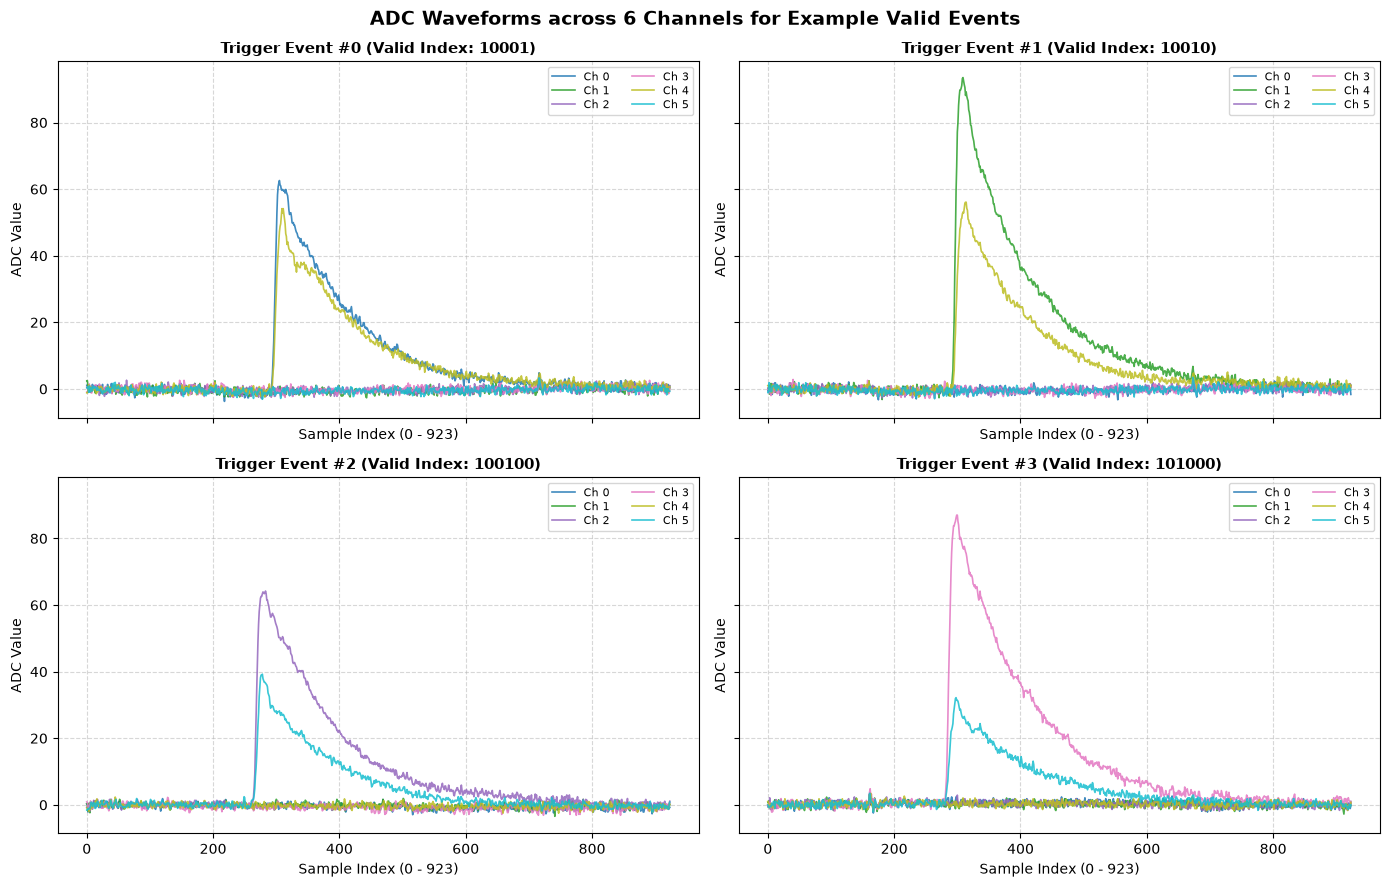

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
axes = axes.flatten()

# Generate distinct titles using valid_indices or custom labels
titles = [
    f"Trigger Event #{idx} (Valid Index: {valid_indices[idx]:b})"
    for idx in range(4)
]

# Color palette for 6 channels
colors = plt.cm.tab10(np.linspace(0, 1, 6))

for i in range(4):
    ax = axes[i]
    event_waveform = example_valid_waveforms[i]  # Shape: (6, 924)

    # Plot each of the 6 channels (924 samples each)
    for ch in range(6):
        ax.plot(
            event_waveform[ch],
            label=f"Ch {ch}",
            color=colors[ch],
            linewidth=1.2,
            alpha=0.85,
        )

    ax.set_title(titles[i], fontsize=11, fontweight="bold")
    ax.set_xlabel("Sample Index (0 - 923)", fontsize=10)
    ax.set_ylabel("ADC Value", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper right", fontsize=8, ncol=2, framealpha=0.8)

plt.suptitle(
    "ADC Waveforms across 6 Channels for Example Valid Events",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()
plt.show()